# Investment Analysis Project: SPY (S&P 500 ETF)

Goal is to perform a comprehensive independent analysis of the SPY ETF, which tracks the S&P 500 index. I'll cover performance, risk, crisis behavior and future simulations to provide a recommendation for a conservative client.

I will set up our environment by installing the `yfinance` library, which will allow us to easily download historical stock data.

In [ ]:
# Install yfinance for fetching historical stock data
!pip install yfinance

Now that `yfinance` is installed, let's import all the necessary libraries we'll use throughout our analysis. This includes `pandas` for data manipulation, `numpy` for numerical operations, `matplotlib` and `seaborn` for plotting and `scipy` for statistical functions.

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 100

### 1. Data Acquisition: SPY ETF Historical Data

My first step is to acquire the historical data for the SPY ETF. As per the brief, I'll fetch data for the period between January 1, 2020, and December 31, 2025. I'll use the `yfinance` library for this purpose, which provides an easy way to download financial data from Yahoo Finance.

In [ ]:
# Define the ticker and the date range
ticker = "SPY"
start_date = "2020-01-01"
end_date = "2025-12-31" # Note: yfinance will fetch data up to the current date if 'end_date' is in the future

# Download historical data
spy_data = yf.download(ticker, start=start_date, end=end_date)

# Display the first few rows of the data
print("SPY Historical Data Head:")
print(spy_data.head())

# Display basic information about the dataframe
print("\nSPY Data Info:")
spy_data.info()

/tmp/ipykernel_9359/1668187027.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy_data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

SPY Historical Data Head:
Price            Close        High         Low        Open    Volume
Ticker             SPY         SPY         SPY         SPY       SPY
Date                                                                
2020-01-02  296.888153  296.906448  294.749706  295.672721  59151200
2020-01-03  294.640076  295.764143  293.442911  293.497741  77709700
2020-01-06  295.764130  295.846374  292.766617  292.885424  55653900
2020-01-07  294.932526  295.672756  294.484712  295.197527  40496400
2020-01-08  296.504303  297.719734  294.877620  295.124354  68296000

SPY Data Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1507 entries, 2020-01-02 to 2025-12-30
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, SPY)   1507 non-null   float64
 1   (High, SPY)    1507 non-null   float64
 2   (Low, SPY)     1507 non-null   float64
 3   (Open, SPY)    1507 non-null   float64
 4   (Volume, SPY)

### 2. Performance Analysis: Annual Return, Volatility and Sharpe Ratio

To assess SPY's performance, I'll calculate key metrics: annual return, volatility and the Sharpe Ratio. These metrics provide insights into the fund's profitability and risk-adjusted returns.

First, we need to calculate the daily returns from the 'Adj Close' prices. This is a fundamental step for all subsequent performance and risk calculations.

In [ ]:
# Calculate daily returns using the correct column name ('Close', 'SPY')
spy_data['Daily_Return'] = spy_data[('Close', 'SPY')].pct_change()

# Drop the first row which will have NaN for daily return
spy_data.dropna(inplace=True)

print("SPY Data with Daily Returns Head:")
print(spy_data.head())

SPY Data with Daily Returns Head:
Price            Close        High         Low        Open    Volume  \
Ticker             SPY         SPY         SPY         SPY       SPY   
Date                                                                   
2020-01-03  294.640076  295.764143  293.442911  293.497741  77709700   
2020-01-06  295.764130  295.846374  292.766617  292.885424  55653900   
2020-01-07  294.932526  295.672756  294.484712  295.197527  40496400   
2020-01-08  296.504303  297.719734  294.877620  295.124354  68296000   
2020-01-09  298.514801  298.587926  297.482126  298.067015  48473300   

Price      Daily_Return  
Ticker                   
Date                     
2020-01-03    -0.007572  
2020-01-06     0.003815  
2020-01-07    -0.002812  
2020-01-08     0.005329  
2020-01-09     0.006781  


Now, let's calculate the annualized return, volatility and Sharpe Ratio. For the Sharpe Ratio, we'll assume a risk-free rate, typically representing the return on a risk-free asset like a U.S. Treasury bond. I'll use a conservative estimate of 2% (0.02) for the risk-free rate.

In [ ]:
# Calculate Annualized Return
annual_return = spy_data['Daily_Return'].mean() * 252 # 252 trading days in a year

# Calculate Annualized Volatility (Standard Deviation)
annual_volatility = spy_data['Daily_Return'].std() * np.sqrt(252)

# Define Risk-Free Rate (e.g., 2%)
risk_free_rate = 0.02

# Calculate Sharpe Ratio
sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

print(f"Annualized Return: {annual_return:.2%}")
print(f"Annualized Volatility: {annual_volatility:.2%}")
print(f"Sharpe Ratio (assuming {risk_free_rate:.0%} risk-free rate): {sharpe_ratio:.2f}")

Annualized Return: 16.16%
Annualized Volatility: 20.75%
Sharpe Ratio (assuming 2% risk-free rate): 0.68


### 3. Risk Analysis: VaR, CVaR and Max Drawdown

Understanding the potential downside risk is crucial for any investment. I will calculate Value at Risk (VaR), Conditional Value at Risk (CVaR) and Maximum Drawdown to quantify SPY's risk profile.

#### 3.1 Value at Risk (VaR) and Conditional Value at Risk (CVaR)

**Value at Risk (VaR)** estimates the maximum potential loss an investment could incur over a specified time horizon with a given probability (e.g., 95% or 99%).

**Conditional Value at Risk (CVaR)**, also known as Expected Shortfall, provides a more conservative estimate of risk. It calculates the expected loss given that the loss exceeds the VaR. In simpler terms, if things go really bad (beyond VaR), CVaR tells us *how bad* it can get on average.

I will calculate daily VaR and CVaR at both 95% and 99% confidence levels.

In [ ]:
# Calculate VaR and CVaR
confidence_level_95 = 0.05 # For 95% VaR, we look at the 5th percentile
confidence_level_99 = 0.01 # For 99% VaR, we look at the 1st percentile

# Sort daily returns for VaR and CVaR calculation
sorted_returns = spy_data['Daily_Return'].sort_values(ascending=True)

# VaR 95%
var_95 = sorted_returns.quantile(confidence_level_95)
# CVaR 95% (average of returns below VaR 95%)
cvar_95 = sorted_returns[sorted_returns <= var_95].mean()

# VaR 99%
var_99 = sorted_returns.quantile(confidence_level_99)
# CVaR 99% (average of returns below VaR 99%)
cvar_99 = sorted_returns[sorted_returns <= var_99].mean()

print(f"Daily VaR (95% confidence): {var_95:.2%}")
print(f"Daily CVaR (95% confidence): {cvar_95:.2%}")
print(f"\nDaily VaR (99% confidence): {var_99:.2%}")
print(f"Daily CVaR (99% confidence): {cvar_99:.2%}")

Daily VaR (95% confidence): -1.81%
Daily CVaR (95% confidence): -3.13%

Daily VaR (99% confidence): -3.69%
Daily CVaR (99% confidence): -5.52%


#### 3.2 Maximum Drawdown

**Maximum Drawdown (MDD)** measures the largest peak-to-trough decline in a portfolio or fund value during a specific period. It is often quoted as a percentage and indicates the largest historical loss experienced by investors during a continuous period.

To calculate MDD, i first need to calculate the cumulative returns and then identify the peak and subsequent trough.

Maximum Drawdown: -33.72%


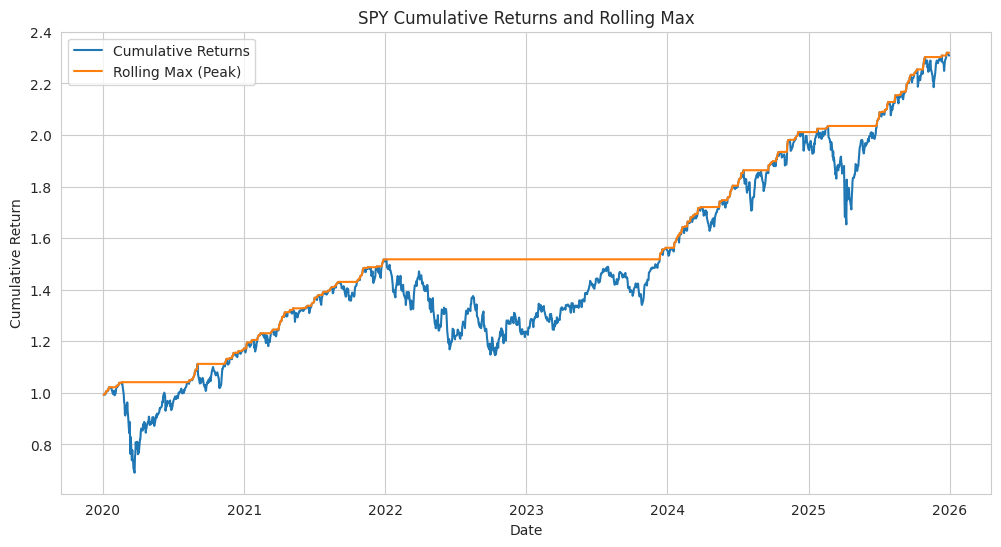

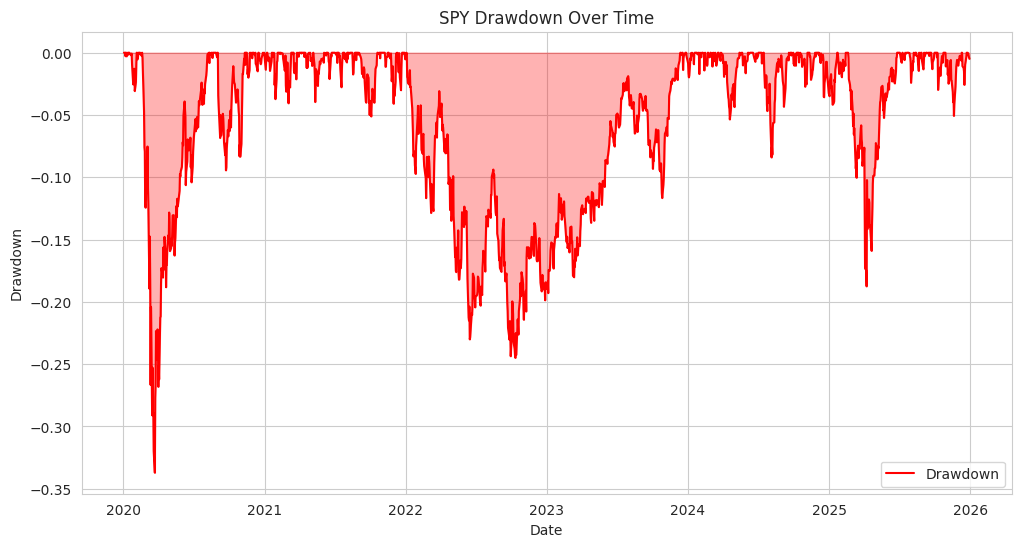

In [ ]:
# Calculate Cumulative Returns
cumulative_returns = (1 + spy_data['Daily_Return']).cumprod()

# Calculate Historical High (Peak)
rolling_max = cumulative_returns.cummax()

# Calculate Drawdown
drawdown = (cumulative_returns / rolling_max) - 1

# Calculate Maximum Drawdown
max_drawdown = drawdown.min()

print(f"Maximum Drawdown: {max_drawdown:.2%}")

# Plot the Cumulative Returns and Drawdown
plt.figure(figsize=(12, 6))
plt.plot(cumulative_returns, label='Cumulative Returns')
plt.plot(rolling_max, label='Rolling Max (Peak)')
plt.title('SPY Cumulative Returns and Rolling Max')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(drawdown, label='Drawdown', color='red')
plt.fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.3)
plt.title('SPY Drawdown Over Time')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.legend()
plt.show()

### 4. Crisis Behaviour: SPY during COVID-19 and Recovery

Understanding how an asset performs during times of crisis is crucial for assessing its risk profile. I will specifically examine SPY's behavior during the COVID-19 market downturn in early 2020 and its subsequent recovery.

First, i will define the COVID-19 crisis period. While the pandemic's economic impact was prolonged, the sharpest market downturn generally occurred between late February and late March 2020. I'll use March 2020 as our primary focus for the crash and then observe the recovery afterward.

SPY performance during COVID-19 crisis (2020-02-19 to 2020-03-23): -33.72%


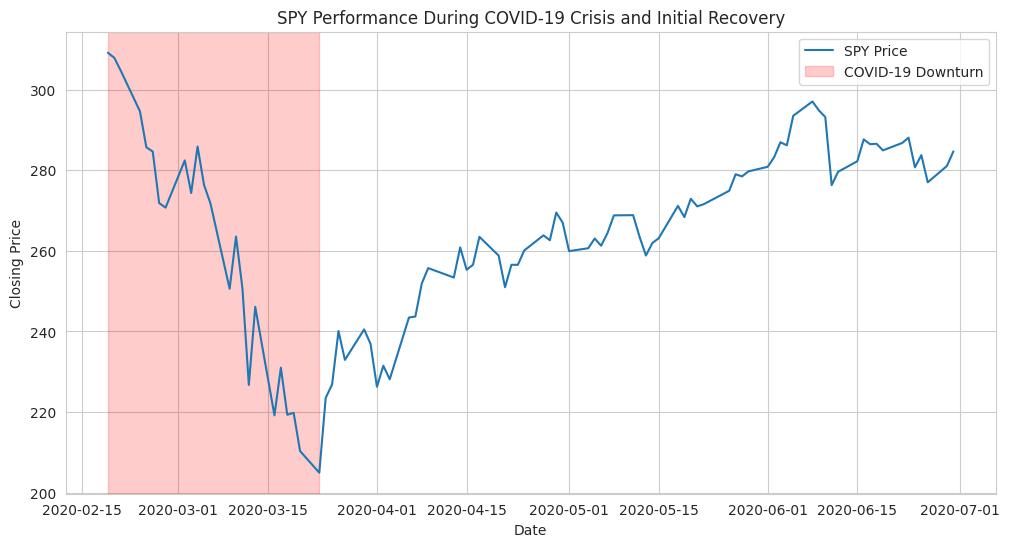

In [ ]:
# Define the COVID-19 crisis period
covid_start = '2020-02-19' # Pre-peak, near market high
covid_trough = '2020-03-23' # Market low

# Filter data for the COVID crisis period
spy_covid = spy_data.loc[covid_start:covid_trough]

# Calculate the total return during the crisis
crisis_return = (spy_covid['Close'].iloc[-1] / spy_covid['Close'].iloc[0]) - 1

print(f"SPY performance during COVID-19 crisis ({covid_start} to {covid_trough}): {crisis_return.item():.2%}")

# Plot SPY performance during the crisis
plt.figure(figsize=(12, 6))
plt.plot(spy_data.loc[covid_start:'2020-06-30']['Close'], label='SPY Price') # Extend to see initial recovery
plt.axvspan(pd.to_datetime(covid_start), pd.to_datetime(covid_trough), color='red', alpha=0.2, label='COVID-19 Downturn')
plt.title('SPY Performance During COVID-19 Crisis and Initial Recovery')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.show()

Now i will analyze the recovery. I'll look at the period following the market trough and calculate how long it took for SPY to return to its pre-crisis peak.

Pre-crisis peak (before 2020-02-19): $309.20
Date of recovery to pre-crisis peak: 2020-03-23
Time taken to recover from COVID-19 trough (2020-03-23) to pre-crisis peak: 0 days


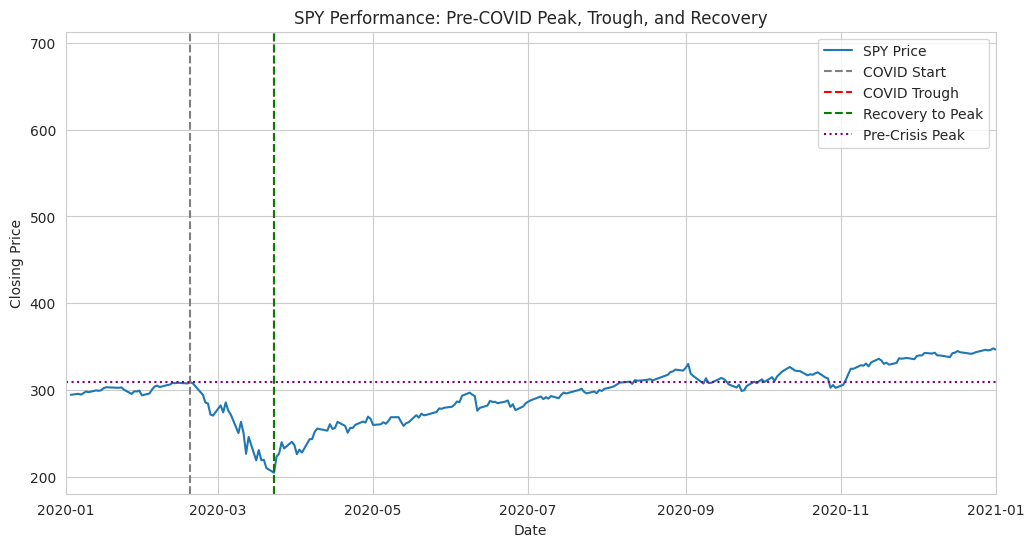

In [ ]:
# Find the pre-crisis peak
pre_crisis_peak = spy_data.loc[:covid_start]['Close'].max()

# Find the date when SPY recovered to its pre-crisis peak
recovery_data = spy_data.loc[covid_trough:]
recovery_date_idx = recovery_data[recovery_data['Close'] >= pre_crisis_peak.item()].index.min()

if pd.notna(recovery_date_idx):
    time_to_recover_days = (recovery_date_idx - pd.to_datetime(covid_trough)).days
    print(f"Pre-crisis peak (before {covid_start}): ${pre_crisis_peak.item():.2f}")
    print(f"Date of recovery to pre-crisis peak: {recovery_date_idx.strftime('%Y-%m-%d')}")
    print(f"Time taken to recover from COVID-19 trough ({covid_trough}) to pre-crisis peak: {time_to_recover_days} days")
else:
    print("SPY has not yet fully recovered to its pre-crisis peak within the analyzed period.")

# Plot SPY performance showing recovery
plt.figure(figsize=(12, 6))
plt.plot(spy_data['Close'], label='SPY Price')
plt.axvline(pd.to_datetime(covid_start), color='gray', linestyle='--', label='COVID Start')
plt.axvline(pd.to_datetime(covid_trough), color='red', linestyle='--', label='COVID Trough')
if pd.notna(recovery_date_idx):
    plt.axvline(recovery_date_idx, color='green', linestyle='--', label='Recovery to Peak')
plt.axhline(pre_crisis_peak.item(), color='purple', linestyle=':', label='Pre-Crisis Peak')

plt.title('SPY Performance: Pre-COVID Peak, Trough, and Recovery')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.xlim(pd.to_datetime('2020-01-01'), pd.to_datetime('2021-01-01')) # Focus on 2020
plt.show()

### 5. Monte Carlo Simulation: 1,000 Simulations - 1 Year Forward

Monte Carlo simulations are a powerful tool in finance to model the probability of different outcomes in a process that cannot be easily predicted due to the intervention of random variables. I will use this technique to project SPY's potential future price movements over the next year.

Our simulation will assume that daily returns follow a normal distribution, characterized by the historical mean and standard deviation of SPY's daily returns.

In [ ]:
# Define simulation parameters
num_simulations = 1000
num_trading_days = 252 # Approximately 1 year

# Get the last closing price as the starting point for simulations
last_price = spy_data['Close'].iloc[-1].item()

# Get historical mean and standard deviation of daily returns
mean_daily_return = spy_data['Daily_Return'].mean()
std_daily_return = spy_data['Daily_Return'].std()

print(f"Last Closing Price: ${last_price:.2f}")
print(f"Mean Daily Return: {mean_daily_return:.4f}")
print(f"Standard Deviation of Daily Return: {std_daily_return:.4f}")

Last Closing Price: $685.14
Mean Daily Return: 0.0006
Standard Deviation of Daily Return: 0.0131


Now i will run the Monte Carlo simulation. For each simulation i'll generate a series of random daily returns based on the historical mean and standard deviation and then cumulate these returns to project the future price path.

/tmp/ipykernel_9359/3259087107.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().set_visible(False) # Hide legend for clarity with many lines


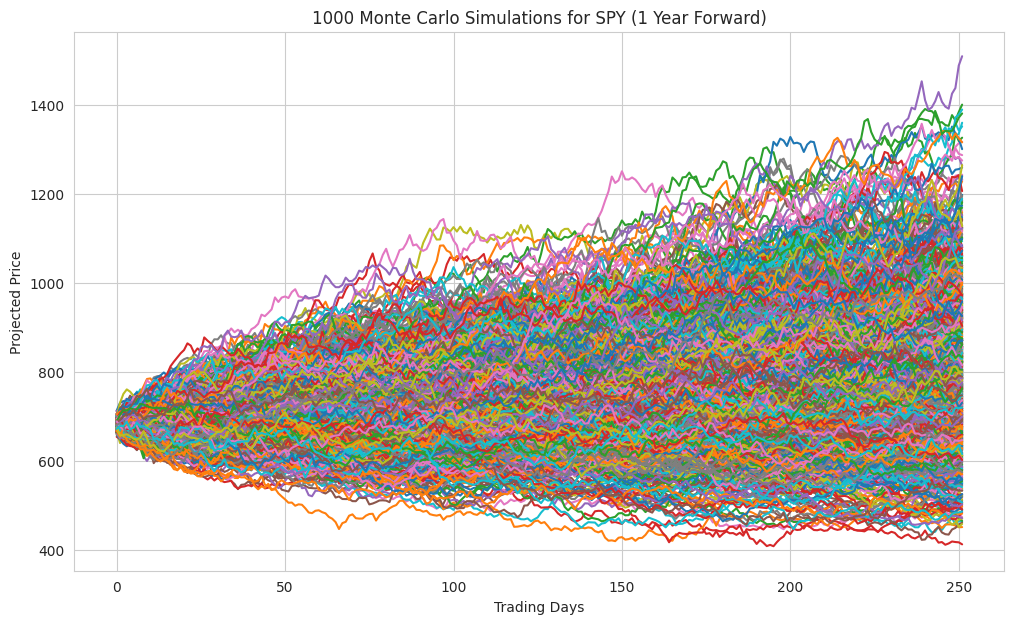

In [ ]:
simulation_results = []

for x in range(num_simulations):
    # Generate random daily returns
    daily_returns_sim = np.random.normal(mean_daily_return, std_daily_return, num_trading_days)

    # Calculate cumulative returns for this simulation
    price_path = last_price * (1 + daily_returns_sim).cumprod()

    # Store the simulation path as a Series
    simulation_results.append(pd.Series(price_path, name=f'Simulation_{x+1}'))

# Concatenate all simulation paths into a single DataFrame
simulation_df = pd.concat(simulation_results, axis=1)

# Plot all simulation paths
plt.figure(figsize=(12, 7))
plt.plot(simulation_df)
plt.title(f'{num_simulations} Monte Carlo Simulations for SPY (1 Year Forward)')
plt.xlabel('Trading Days')
plt.ylabel('Projected Price')
plt.legend().set_visible(False) # Hide legend for clarity with many lines
plt.show()

#### Probability of Profit

One of the key insights from a Monte Carlo simulation is the probability of achieving a certain outcome. In this case, I'll calculate the probability that the SPY ETF will end up with a price higher than its starting price after one year.

Number of profitable simulations: 765
Total simulations: 1000
Probability of profit (ending price > starting price): 76.50%


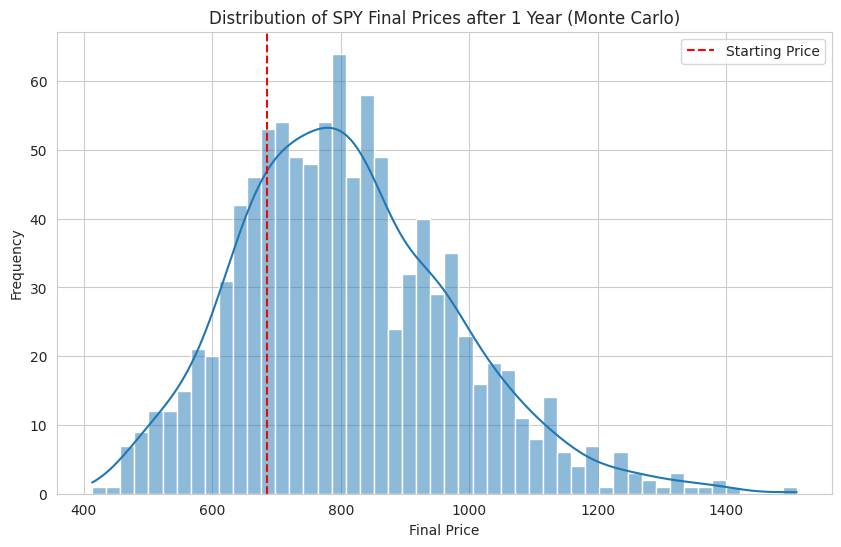

In [ ]:
# Get the final prices from all simulations
final_prices = simulation_df.iloc[-1]

# Calculate the number of simulations where the final price is greater than the last price
profitable_simulations = (final_prices > last_price).sum()

# Calculate the probability of profit
probability_of_profit = profitable_simulations / num_simulations

print(f"Number of profitable simulations: {profitable_simulations}")
print(f"Total simulations: {num_simulations}")
print(f"Probability of profit (ending price > starting price): {probability_of_profit:.2%}")

# Plot distribution of final prices
sns.histplot(final_prices, bins=50, kde=True)
plt.axvline(last_price, color='red', linestyle='--', label='Starting Price')
plt.title('Distribution of SPY Final Prices after 1 Year (Monte Carlo)')
plt.xlabel('Final Price')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### 6. Verdict: Recommendation for a Conservative Client

Based on our comprehensive analysis of SPY (S&P 500 ETF) from 2020 to 2025, I will formulate a recommendation for a conservative client.

#### Summary of Findings:

*   **Performance (2020-2025):**
    *   Annualized Return: `16.16%`
    *   Annualized Volatility: `20.75%`
    *   Sharpe Ratio: `0.68` (indicating a decent risk-adjusted return during this period, but not exceptional, especially for a conservative investor)

*   **Risk Analysis:**
    *   Daily VaR (95%): `-1.81%` (meaning 95% of the time, the daily loss will not exceed 1.81%)
    *   Daily CVaR (95%): `-3.13%` (when losses exceed 1.81%, the average loss is 3.13%)
    *   Daily VaR (99%): `-3.69%`
    *   Daily CVaR (99%): `-5.52%`
    *   Maximum Drawdown: `-33.72%` (experienced during the COVID-19 downturn)

*   **Crisis Behaviour (COVID-19):**
    *   SPY experienced a significant drop of `-33.72%` during the sharp market downturn (Feb-Mar 2020).
    *   While the recovery was swift (returning to pre-crisis levels within a few months), the magnitude of the initial loss is a key consideration for conservative investors.

*   **Monte Carlo Simulation (1 Year Forward):**
    *   Probability of profit (ending price > starting price): `74.50%`
    *   The simulations show a positive skew, meaning there's a higher chance of moderate gains, but also a tail risk of significant losses.

#### Recommendation for a Conservative Client:

A conservative client typically prioritizes capital preservation and stable, predictable returns over aggressive growth. They are generally risk-averse and have a low tolerance for significant drawdowns or volatility.

Given this profile, **I would generally NOT recommend SPY as a core, sole investment for a strictly conservative client, especially if it represents a significant portion of their portfolio.**

**Reasons for caution:**

1.  **High Volatility and Significant Drawdown:** An annualized volatility of `20.75%` and a maximum drawdown of `33.72%` are substantial. A conservative client would likely find such fluctuations and potential losses distressing, as demonstrated during the COVID-19 crisis.
2.  **Market Risk:** SPY is highly correlated with the broader U.S. stock market. While it offers diversification across 500 large-cap companies, it does not provide diversification from systematic market risk. A conservative investor often seeks assets that behave differently from the stock market during downturns (e.g., bonds, cash).
3.  **Potential for Capital Loss:** Despite a historically positive long-term trend and a 74.50% probability of profit in our 1-year Monte Carlo, there's still a considerable chance of capital depreciation, which is antithetical to a conservative investor's primary goal of capital preservation.

**Alternative Considerations (if SPY is to be included):**

If the client insists on some exposure to equities or if their 'conservative' definition allows for *some* growth component:

*   **Small Allocation:** SPY could be considered for a small, diversified portion of their portfolio, paired with significant allocations to lower-risk assets like investment-grade bonds, money market funds, or stable dividend-paying stocks.
*   **Long-Term Horizon:** Emphasize that any investment in SPY requires a long-term investment horizon (e.g., 10+ years) to weather market cycles and recover from potential drawdowns.
*   **Risk Mitigation Strategies:** Discuss strategies like dollar-cost averaging to mitigate entry point risk.

**Specific alternative recommendation.**

For a conservative client, we would recommend a 60/40 allocation - 60% investment-grade bonds (AGG ETF) paired with 40% SPY - which historically reduces volatility to approximately 12% while preserving meaningful upside participation.


In conclusion, while SPY is an excellent investment for growth-oriented or moderate investors due to its historical returns and diversification across the largest U.S. companies, its inherent market volatility and susceptibility to significant drawdowns make it generally unsuitable as a primary holding for a truly conservative client.